# DATA PREPROCESSING AND FEATURE ENGINEERING FOR NYC AIRBNB DATASET

**DATA COLLECTION**

In [2]:
# importing necessary library

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('AB_NYC_2019.csv')

In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


**DESCRIPTION ABOUT THE COLUMNS**

| Column                                | Meaning                                                                                      |
| ------------------------------------- | -------------------------------------------------------------------------------------------- |
| **id**                                | Unique ID for each listing.                                                                  |
| **name**                              | Title/description of the Airbnb listing.                                                     |
| **host\_id**                          | Unique ID of the host (person renting out property).                                         |
| **host\_name**                        | Name of the host.                                                                            |
| **neighbourhood\_group**              | The borough of NYC (e.g., Brooklyn, Manhattan, Queens, Bronx, Staten Island).                |
| **neighbourhood**                     | Specific neighborhood within the borough (e.g., Kensington, Harlem, Midtown).                |
| **latitude**                          | Geographic latitude of the listing (used for mapping).                                       |
| **longitude**                         | Geographic longitude of the listing (used for mapping).                                      |
| **room\_type**                        | Type of listing: *Entire home/apt, Private room, Shared room, Hotel room*.                   |
| **price**                             | Price per night in USD.                                                                      |
| **minimum\_nights**                   | Minimum number of nights required to book.                                                   |
| **number\_of\_reviews**               | Total number of reviews the listing has received.                                            |
| **last\_review**                      | Date of the most recent review (if available).                                               |
| **reviews\_per\_month**               | Average number of reviews the listing gets per month.                                        |
| **calculated\_host\_listings\_count** | Number of listings that the same host has (1 = single listing host, higher = business host). |
| **availability\_365**                 | Number of days in a year the listing is available (0–365).                                   |


In [5]:
# ROWS AND COLUMNS
df.shape

(48895, 16)

**COUNTING NULL VALUES**

In [6]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Last_Review and reviews_per_month got the highest null values

**BASIC INFO ABOUT THE DATASET**

In [7]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


HERE MINIMUM PRICE == 0 , WHICH IS UNUSUAL IN AIRBNB

MINIMUM NIGHT == 1250, WHICH IS UNUSUAL IN AIRBNB

CALCULATED HOST LISTING IS ALSO == 327 WHICH SEEMS UNUSUAL

**COLUMNS OF THE DATASET**

In [8]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

**NUMERICAL AND CATEGORICAL VARIABLES**

In [10]:
numerical_cols = df.select_dtypes(include=['number']).columns
numerical_cols

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')

**NUMBER OF NUMERICAL AND CATEGORICAL COLUMN**

In [12]:
#Numerical
len(numerical_cols)

10

In [13]:
#Categorical
len(categorical_cols)

6

**DUPLICATE VALUES**

In [14]:
df.duplicated().sum()

0

we got no duplicate values

**COUNTING UNIQUE VALUES**

In [15]:
cols = df.columns
for i in cols:
    print(f'No. of unique values in {i}: ', df[i].nunique())

No. of unique values in id:  48895
No. of unique values in name:  47905
No. of unique values in host_id:  37457
No. of unique values in host_name:  11452
No. of unique values in neighbourhood_group:  5
No. of unique values in neighbourhood:  221
No. of unique values in latitude:  19048
No. of unique values in longitude:  14718
No. of unique values in room_type:  3
No. of unique values in price:  674
No. of unique values in minimum_nights:  109
No. of unique values in number_of_reviews:  394
No. of unique values in last_review:  1764
No. of unique values in reviews_per_month:  937
No. of unique values in calculated_host_listings_count:  47
No. of unique values in availability_365:  366


***

## DATA CLEANING

**COLUMN BY COLUMN**

In [16]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


**#NAME COLUMN**

Checking unique values

In [17]:
df['name'].unique()

array(['Clean & quiet apt home by the park', 'Skylit Midtown Castle',
       'THE VILLAGE OF HARLEM....NEW YORK !', ...,
       'Sunny Studio at Historical Neighborhood',
       '43rd St. Time Square-cozy single bed',
       "Trendy duplex in the very heart of Hell's Kitchen"], dtype=object)

In [18]:
df['name'].isnull().sum()

16

Getting rows that are null

In [19]:
df[df['name'].isna()].head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2854,1615764,NaN,6676776,Peter,Manhattan,Battery Park City,40.71239,-74.01620,Entire home/apt,400,1000,0,NaN,NaN,1,362
3703,2232600,NaN,11395220,Anna,Manhattan,East Village,40.73215,-73.98821,Entire home/apt,200,1,28,2015-06-08,0.45,1,341
5775,4209595,NaN,20700823,Jesse,Manhattan,Greenwich Village,40.73473,-73.99244,Entire home/apt,225,1,1,2015-01-01,0.02,1,0
5975,4370230,NaN,22686810,Michaël,Manhattan,Nolita,40.72046,-73.99550,Entire home/apt,215,7,5,2016-01-02,0.09,1,0
6269,4581788,NaN,21600904,Lucie,Brooklyn,Williamsburg,40.71370,-73.94378,Private room,150,1,0,NaN,NaN,1,0


Filling null values in name with 'Unknown'

In [20]:
df['name'].fillna('Unknown',inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_18768\51188484.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['name'].fillna('Unknown',inplace=True)


In [21]:
df[df['name'].isna()].head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


In [22]:
df['name'].nunique()

47906

In [23]:
df['name'].duplicated(
).sum()

989

Getting duplicated rows to see if only name are duplicated or whole row

In [24]:
df[df.duplicated(subset=['name'],keep=False)].sort_values('name').head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
34347,27237604,*NO GUEST SERVICE FEE* Luxury Midtown One Bedr...,205031545,Red Awning,Manhattan,Midtown,40.75294,-73.96731,Entire home/apt,737,3,2,2019-06-07,0.40,49,235
34352,27237625,*NO GUEST SERVICE FEE* Luxury Midtown One Bedr...,205031545,Red Awning,Manhattan,Midtown,40.75459,-73.96707,Entire home/apt,737,3,3,2019-06-10,0.44,49,153
42817,33241978,1 BR Suite in Midtown Manhattan,24831061,Hosteeva,Manhattan,Midtown,40.76391,-73.98071,Private room,250,1,0,NaN,NaN,8,0
42776,33216329,1 BR Suite in Midtown Manhattan,24831061,Hosteeva,Manhattan,Midtown,40.76453,-73.98035,Private room,250,1,0,NaN,NaN,8,0
9250,7071657,1 BR UPPER EAST SIDE,4909308,Francesco,Manhattan,Upper East Side,40.77344,-73.95035,Entire home/apt,243,1,26,2019-06-22,1.10,1,149


Those duplicate values mean the dataset contains different records of the same Airbnb listing taken at different times or with slight variations, not true errors.

***

**#host_id**

In [25]:
df['host_id'].isnull().sum()

0

In [26]:
df['host_id'].unique()


array([     2787,      2845,      4632, ..., 274321313,  23492952,
        68119814], dtype=int64)

***

**#Host name**

In [27]:
df['host_name'].isnull().sum()


21

Getting Rows with no host name

In [28]:
df[df['host_name'].isna()].head(
    )



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
360,100184,Bienvenue,526653,NaN,Queens,Queens Village,40.72413,-73.76133,Private room,50,1,43,2019-07-08,0.45,1,88
2700,1449546,Cozy Studio in Flatbush,7779204,NaN,Brooklyn,Flatbush,40.64965,-73.96154,Entire home/apt,100,30,49,2017-01-02,0.69,1,342
5745,4183989,SPRING in the City!! Zen-Style Tranquil Bedroom,919218,NaN,Manhattan,Harlem,40.80606,-73.95061,Private room,86,3,34,2019-05-23,1.00,1,359
6075,4446862,Charming Room in Prospect Heights!,23077718,NaN,Brooklyn,Crown Heights,40.67512,-73.96146,Private room,50,1,0,NaN,NaN,1,0
6582,4763327,"Luxurious, best location, spa inc'l",24576978,NaN,Brooklyn,Greenpoint,40.72035,-73.95355,Entire home/apt,195,1,1,2015-10-20,0.02,1,0


Filling null vaues with unknown

In [29]:
df['host_name'].fillna('Unknown',inplace= True)

C:\Users\user\AppData\Local\Temp\ipykernel_18768\2962016353.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_name'].fillna('Unknown',inplace= True)


In [30]:
df['host_name'].isnull().sum()


0

***

**#Neighbouor hood group**

In [31]:
df['neighbourhood_group'].isnull().sum()

0

In [32]:
df['neighbourhood_group'].unique()


array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

Everything seems okay

***

**#Neighbourhood**

In [33]:
df['neighbourhood'].isnull().sum()

0

In [34]:
df['neighbourhood'].unique()


array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', 'Bedford-Stuyvesant', "Hell's Kitchen",
       'Upper West Side', 'Chinatown', 'South Slope', 'West Village',
       'Williamsburg', 'Fort Greene', 'Chelsea', 'Crown Heights',
       'Park Slope', 'Windsor Terrace', 'Inwood', 'East Village',
       'Greenpoint', 'Bushwick', 'Flatbush', 'Lower East Side',
       'Prospect-Lefferts Gardens', 'Long Island City', 'Kips Bay',
       'SoHo', 'Upper East Side', 'Prospect Heights',
       'Washington Heights', 'Woodside', 'Brooklyn Heights',
       'Carroll Gardens', 'Gowanus', 'Flatlands', 'Cobble Hill',
       'Flushing', 'Boerum Hill', 'Sunnyside', 'DUMBO', 'St. George',
       'Highbridge', 'Financial District', 'Ridgewood',
       'Morningside Heights', 'Jamaica', 'Middle Village', 'NoHo',
       'Ditmars Steinway', 'Flatiron District', 'Roosevelt Island',
       'Greenwich Village', 'Little Italy', 'East Flatbush',
       'Tompkinsville', 'Asto

***

**#Latitude and Longititude**

In [35]:
df['latitude'].isnull().sum()

0

In [36]:
df['latitude'].unique()


array([40.64749, 40.75362, 40.80902, ..., 40.80953, 40.70184, 40.81475])

In [37]:
df['latitude'].dtype

dtype('float64')

In [38]:
df['latitude'].nunique()


19048

In [39]:
df['longitude'].isnull().sum()


0

In [40]:
df['longitude'].unique()


array([-73.97237, -73.98377, -73.9419 , ..., -73.87727, -73.93614,
       -73.80844])

In [41]:
df['longitude'].nunique()


14718

In [42]:
df['latitude'].describe()


count    48895.000000
mean        40.728949
std          0.054530
min         40.499790
25%         40.690100
50%         40.723070
75%         40.763115
max         40.913060
Name: latitude, dtype: float64

In [43]:
df['longitude'].describe()

count    48895.000000
mean       -73.952170
std          0.046157
min        -74.244420
25%        -73.983070
50%        -73.955680
75%        -73.936275
max        -73.712990
Name: longitude, dtype: float64

The latitude and longitude values in the dataset are consistent with New York City’s geographic range.

***

**#Room TYPE**

In [44]:
df['room_type'].isnull().sum()

0

In [45]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

***

**#PRICE**

In [46]:
df.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355


Earlier we noticed outlier in price

In [47]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [48]:
df=df[df['price']>0] # we will only keep rows that have price greater than 0

In [49]:
df['price'].describe()


count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

***

There isnt much to clean so lets jump to reviews per month it got object dtype

In [50]:
df['reviews_per_month'].unique()

array([2.100e-01, 3.800e-01,       nan, 4.640e+00, 1.000e-01, 5.900e-01,
       4.000e-01, 3.470e+00, 9.900e-01, 1.330e+00, 4.300e-01, 1.500e+00,
       1.340e+00, 9.100e-01, 2.200e-01, 1.200e+00, 1.720e+00, 2.120e+00,
       4.440e+00, 7.000e-02, 1.090e+00, 3.700e-01, 6.100e-01, 7.300e-01,
       1.370e+00, 4.900e-01, 1.110e+00, 2.400e-01, 2.040e+00, 1.420e+00,
       1.650e+00, 2.370e+00, 6.600e-01, 1.410e+00, 1.960e+00, 1.810e+00,
       2.080e+00, 3.900e-01, 2.300e-01, 6.900e-01, 8.400e-01, 2.250e+00,
       5.200e-01, 1.160e+00, 1.010e+00, 6.300e-01, 7.000e-01, 2.820e+00,
       9.000e-01, 1.700e-01, 2.490e+00, 1.190e+00, 3.000e-01, 1.200e-01,
       5.700e-01, 1.600e-01, 4.720e+00, 1.400e+00, 1.260e+00, 1.640e+00,
       1.600e+00, 9.200e-01, 2.000e-01, 1.280e+00, 5.400e-01, 6.200e-01,
       1.500e-01, 5.300e-01, 1.730e+00, 5.000e-02, 1.540e+00, 2.800e-01,
       3.400e+00, 1.570e+00, 1.050e+00, 7.100e-01, 1.100e-01, 2.700e-01,
       1.230e+00, 8.700e-01, 2.090e+00, 6.000e-01, 

In [51]:
df['reviews_per_month'].isnull().sum()

10051

Filling these with 0

In [52]:
df['reviews_per_month'].fillna(0,inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_18768\775648051.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0,inplace=True)


In [53]:
df['reviews_per_month'] = df['reviews_per_month'].astype(float)


In [54]:
df['reviews_per_month'].dtype

dtype('float64')

***

**#LAST_REVIEW**

In [55]:
df['last_review'].unique()

array(['2018-10-19', '2019-05-21', nan, ..., '2017-12-23', '2018-01-29',
       '2018-03-29'], dtype=object)

In [56]:
df[df['last_review'].isna()].head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.0,1,365
19,7750,Huge 2 BR Upper East Cental Park,17985,Sing,Manhattan,East Harlem,40.79685,-73.94872,Entire home/apt,190,7,0,NaN,0.0,2,249
26,8700,Magnifique Suite au N de Manhattan - vue Cloitres,26394,Claude & Sophie,Manhattan,Inwood,40.86754,-73.92639,Private room,80,4,0,NaN,0.0,1,0
36,11452,Clean and Quiet in Brooklyn,7355,Vt,Brooklyn,Bedford-Stuyvesant,40.68876,-73.94312,Private room,35,60,0,NaN,0.0,1,365
38,11943,Country space in the city,45445,Harriet,Brooklyn,Flatbush,40.63702,-73.96327,Private room,150,1,0,NaN,0.0,1,365


First we will convert last_reviews into data and time format then take out date, month and year then handle null values

In [57]:
df['last_review']= pd.to_datetime(df['last_review'])

In [58]:
df['last_review_year'] = df['last_review'].dt.year
df['last_review_month'] = df['last_review'].dt.month
df['last_review_date'] = df['last_review'].dt.day

In [59]:
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,last_review_date
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,2018.0,10.0,19.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,2019.0,5.0,21.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,NaN,NaN,NaN


since, if number of reviews  is 0 then there wont be last review date so making all nan values 0 where number of reviews == 0

In [60]:
df.loc[df['number_of_reviews']== 0,['last_review_year','last_review_month','last_review_date']] = 0

In [61]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10051
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
last_review_year                      0
last_review_month                     0
last_review_date                      0
dtype: int64

lets drop last_review since we already extracted data from there

In [62]:
df.drop('last_review',inplace=True,axis=1)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48884 entries, 0 to 48894
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48884 non-null  int64  
 1   name                            48884 non-null  object 
 2   host_id                         48884 non-null  int64  
 3   host_name                       48884 non-null  object 
 4   neighbourhood_group             48884 non-null  object 
 5   neighbourhood                   48884 non-null  object 
 6   latitude                        48884 non-null  float64
 7   longitude                       48884 non-null  float64
 8   room_type                       48884 non-null  object 
 9   price                           48884 non-null  int64  
 10  minimum_nights                  48884 non-null  int64  
 11  number_of_reviews               48884 non-null  int64  
 12  reviews_per_month               48884

***

## EDA


In [64]:
df.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,last_review_date
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,2018.0,10.0,19.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2019.0,5.0,21.0


## Bivariate chart for numerical variable

**MINIMUM NIGHT VS PRICE**

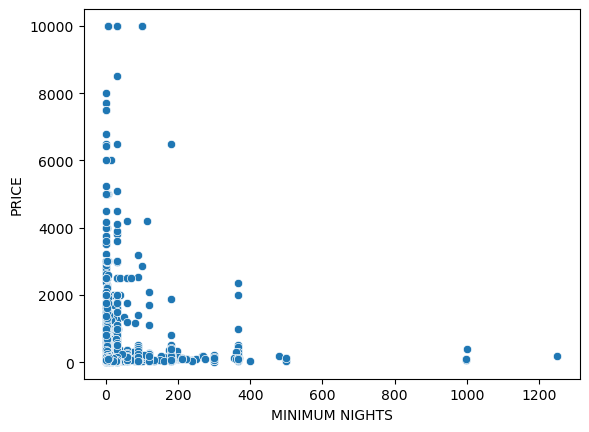

In [65]:
plt.Figure(figsize=(15,12))
sns.scatterplot(data=df, x='minimum_nights',y='price')
plt.xlabel('MINIMUM NIGHTS')
plt.ylabel('PRICE')
plt.show()

## OBSERVATION

most of the data are cluster between 0 and around 150 minimum nights

there are minimum nights that are == or > 1000 as well which seems unusual for airbnb dataset



**FILTERING OUT MINIMUM NIGHTS THAT ARE LESS THAN 180 DAYS**

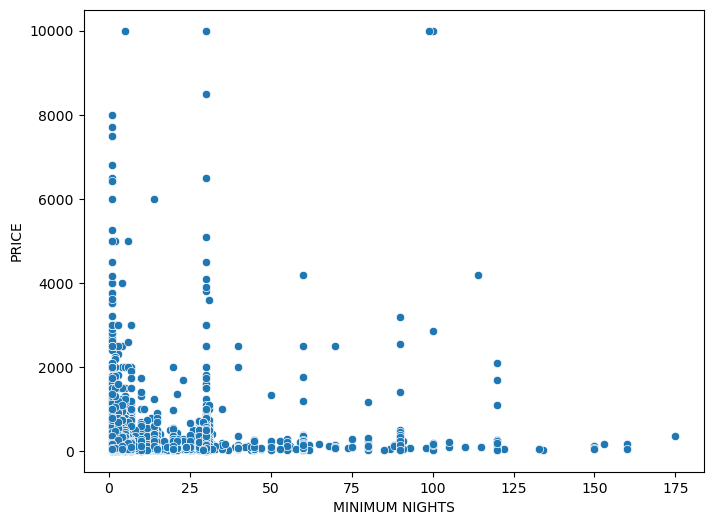

In [66]:
plt.figure(figsize=(8,6))
sns.scatterplot(x= df.loc[df['minimum_nights']<180,'minimum_nights'],
                y=df.loc[df['minimum_nights']<180,'price'])
plt.xlabel('MINIMUM NIGHTS')
plt.ylabel('PRICE')
plt.show()

## OBSERVATION

Most of the airbnb has minimum  night from 1 to 30

there are only few airbnb that has minimum night >125 and less than 180 days

altho few airbnb has minimum requirement of more than 125 nights, that are at very cheap cost

**lets also handle outlier and then have a closer look**

#5 number summary

In [67]:
minimum,q1,median,q3,maximum=np.quantile(df.loc[df['minimum_nights']<180,'price'],[0,0.25,0.5,0.75,1])


In [68]:
iqr=q3-q1

In [69]:
iqr

106.0

In [70]:

upper_fence=q3+1.5*iqr

In [71]:

print("upper fence: ",upper_fence)


upper fence:  334.0


so we have our upper limit for price lets re calculate scatter plot base on this

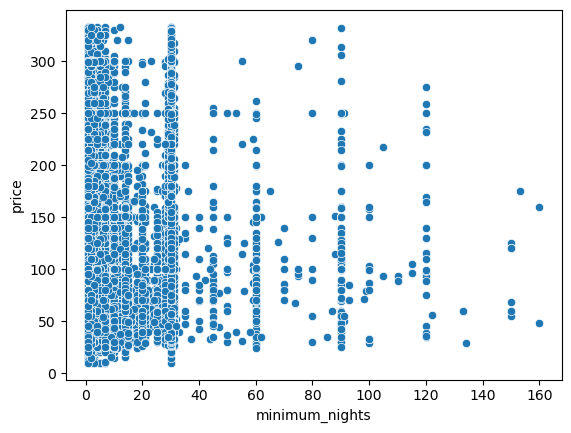

In [72]:
sns.scatterplot(x=df.loc[(df['minimum_nights']<180) & (df['price']<334),'minimum_nights'],
                y=df.loc[(df['minimum_nights']<180) & (df['price']<334),'price'])
plt.show()

***

**AVAILABILITY**

In [73]:
numerical_cols

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [74]:
categorical_cols

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')

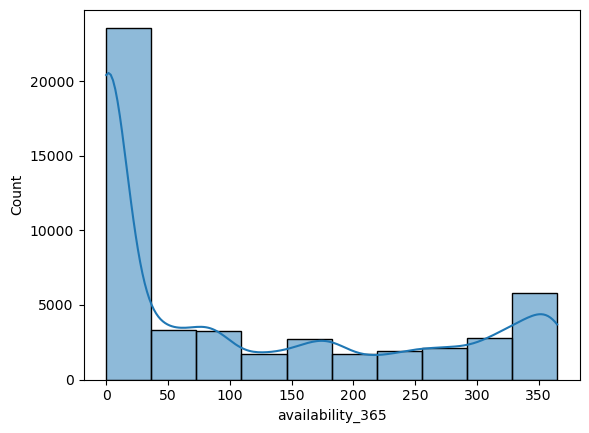

In [75]:
sns.histplot(data=df, x='availability_365',bins=10,kde=True)
plt.show()

Most listings have 0 availability days (not available for booking at all).

A small number of listings have 1–30 availability days, but the count drops sharply after 30.

Availability is fairly low between 50 to 250 days, showing scattered but smaller peaks.

A noticeable cluster appears again around 365 days, meaning many listings are available throughout the whole year.

The distribution is heavily right-skewed, dominated by 0 and 365-day availabilities.

**LATITUDE AND LONGITITUDE**

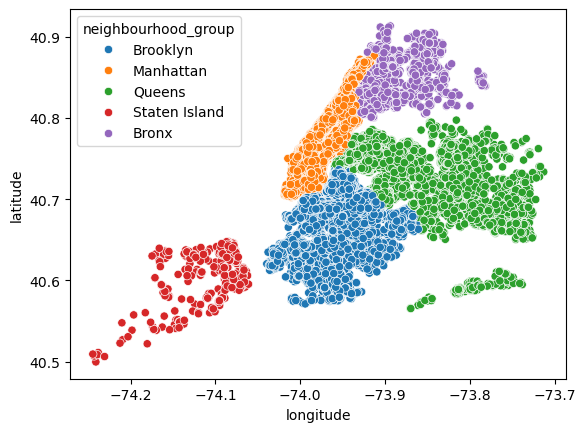

In [76]:
sns.scatterplot(data=df, x='longitude', y= 'latitude',hue='neighbourhood_group')
plt.show()

**TOP HOST WITH HIGHEST LISTING**

In [77]:
max_list_host= df.groupby('host_id')['calculated_host_listings_count'].max().sort_values(ascending=False).head(5).reset_index()

In [78]:
max_list_host

,host_id,calculated_host_listings_count
0,219517861,327
1,107434423,232
2,30283594,121
3,137358866,103
4,12243051,96


<Axes: xlabel='host_id', ylabel='calculated_host_listings_count'>

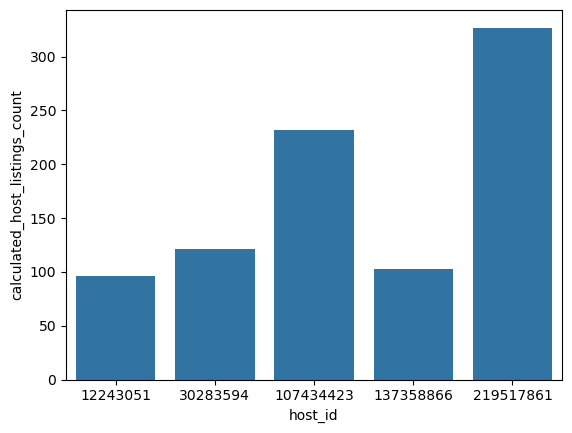

In [79]:
sns.barplot(data=max_list_host,x='host_id',y='calculated_host_listings_count')

In [80]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,last_review_date
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,2018.0,10.0,19.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2019.0,5.0,21.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,0.0,0.0,0.0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,2019.0,7.0,5.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,2018.0,11.0,19.0


**TOP 5 HIGHER PRICE HOTEL LISTED BY POPULAR HOST**

In [81]:
top_5_host_list = max_list_host['host_id']


In [82]:
top_5_host_list

0    219517861
1    107434423
2     30283594
3    137358866
4     12243051
Name: host_id, dtype: int64

In [83]:
df1=df.groupby(['host_id','name'])['price'].max().sort_values(ascending=False).reset_index()

In [84]:
df1.head()

,host_id,name,price
0,20582832,Furnished room in Astoria apartment,10000
1,72390391,1-BR Lincoln Center,10000
2,5143901,Luxury 1 bedroom apt. -stunning Manhattan views,10000
3,3906464,"Quiet, Clean, Lit @ LES & Chinatown",9999
4,4382127,2br - The Heart of NYC: Manhattans Lower East ...,9999


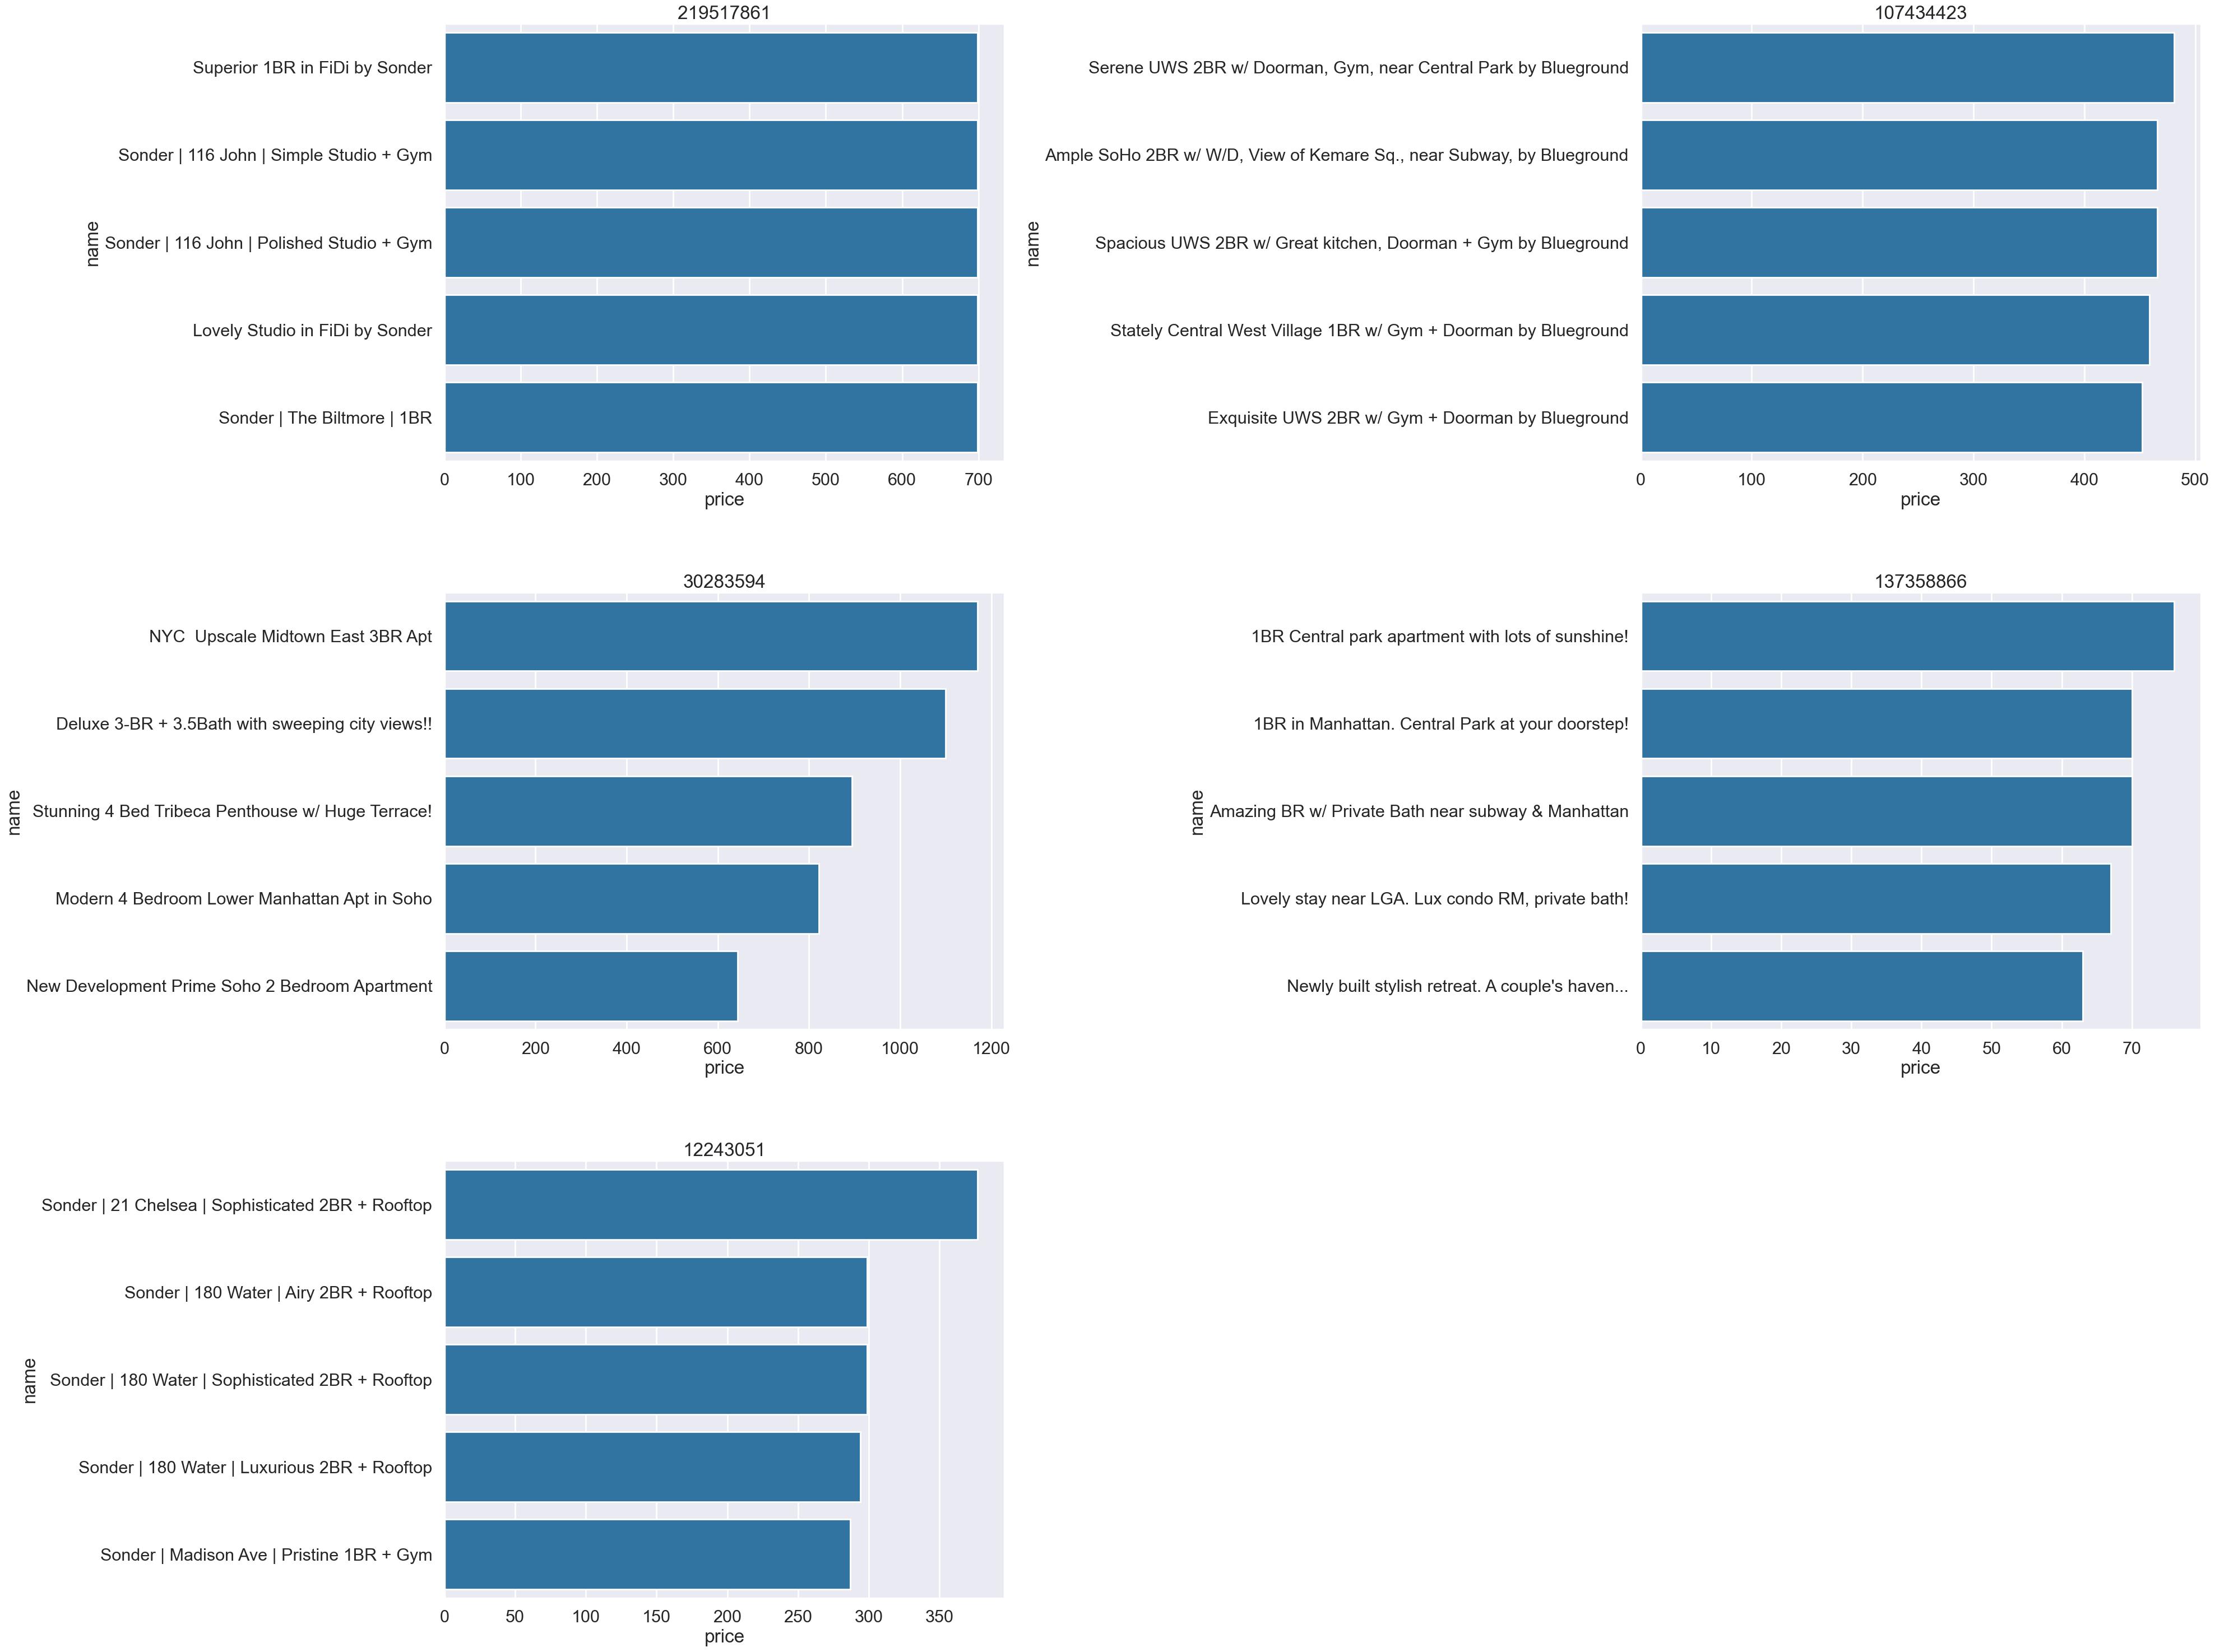

In [85]:
plt.figure(figsize=(40,30))
sns.set_context("poster")
sns.set_style("darkgrid")
for i, cols in enumerate(top_5_host_list,1):
    df2= df1[df1['host_id']==cols]
    df3=df2.head()
    plt.subplot(3,2,i)
    sns.barplot(data=df3,y='name', x = 'price')
    plt.title(cols)
plt.tight_layout()
plt.subplots_adjust(hspace= .3)
plt.show()

## Univariate (single categorical variable)

In [86]:
categorical_cols

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')

**MOST POPULAR NEIGHBOURHOOD GROUP**

C:\Users\user\AppData\Local\Temp\ipykernel_18768\1746035737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,y='neighbourhood_group', palette='Set2')


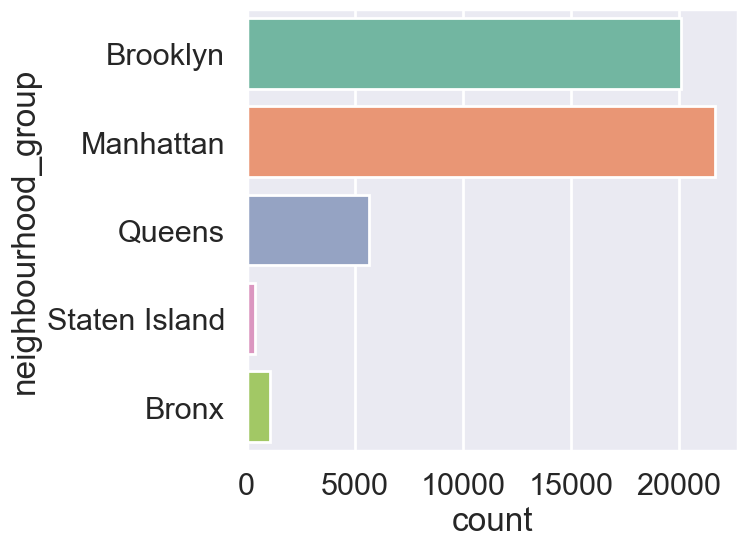

In [87]:
# countplot

plt.figure(figsize=(8,6))
sns.set_context("poster")
sns.set_style("darkgrid")
sns.countplot(data=df,y='neighbourhood_group', palette='Set2')
plt.tight_layout()
plt.show()

**TOP 5 NEIGHBOURHOOD**

In [88]:
Top_5_Neighbourhood = df['neighbourhood'].value_counts().sort_values(ascending=False).head(5).reset_index()

In [89]:
Top_5_Neighbourhood

,neighbourhood,count
0,Williamsburg,3919
1,Bedford-Stuyvesant,3710
2,Harlem,2658
3,Bushwick,2462
4,Upper West Side,1971


C:\Users\user\AppData\Local\Temp\ipykernel_18768\1113712206.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Top_5_Neighbourhood,y='neighbourhood',x='count', palette='Set2')


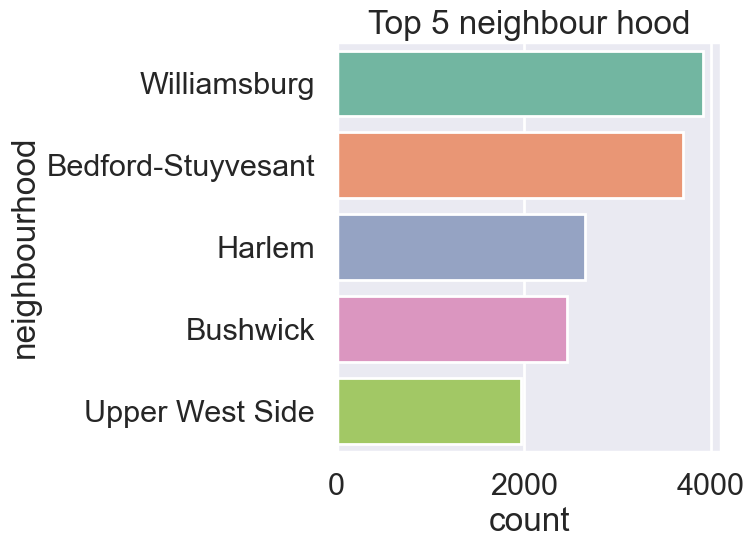

In [90]:


plt.figure(figsize=(8,6))
sns.set_context("poster")
sns.set_style("darkgrid")
sns.barplot(data=Top_5_Neighbourhood,y='neighbourhood',x='count', palette='Set2')
plt.title('Top 5 neighbour hood')
plt.tight_layout()
plt.show()

**POPULAR ROOP TYPE**


In [91]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

C:\Users\user\AppData\Local\Temp\ipykernel_18768\3745028741.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,y='room_type', palette='Set2')


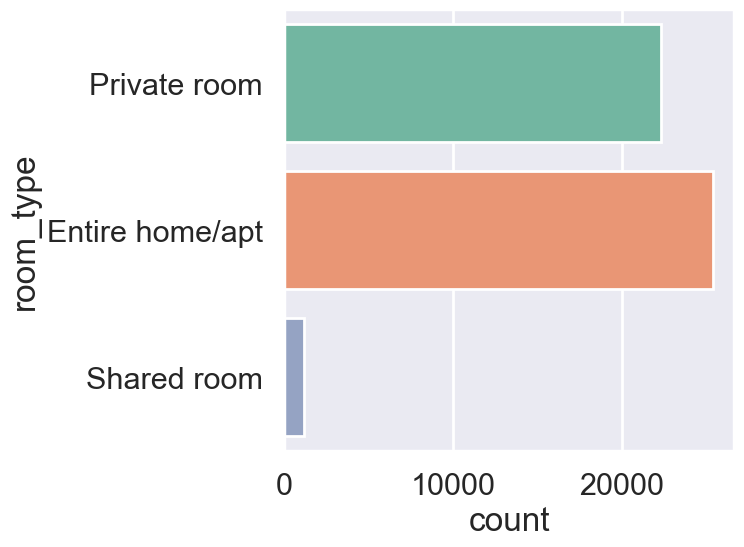

In [92]:
# countplot

plt.figure(figsize=(8,6))
sns.set_context("poster")
sns.set_style("darkgrid")
sns.countplot(data=df,y='room_type', palette='Set2')
plt.tight_layout()
plt.show()

**NO. OF ROOM TYPE IN EACH NEIGHBOURHOOD GROUP**

In [93]:
# Heatmap of two categorical variable
ct=pd.crosstab(df['neighbourhood_group'],df['room_type'])


In [94]:
ct

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,379,651,60
Brooklyn,9558,10126,411
Manhattan,13198,7982,480
Queens,2096,3372,198
Staten Island,176,188,9


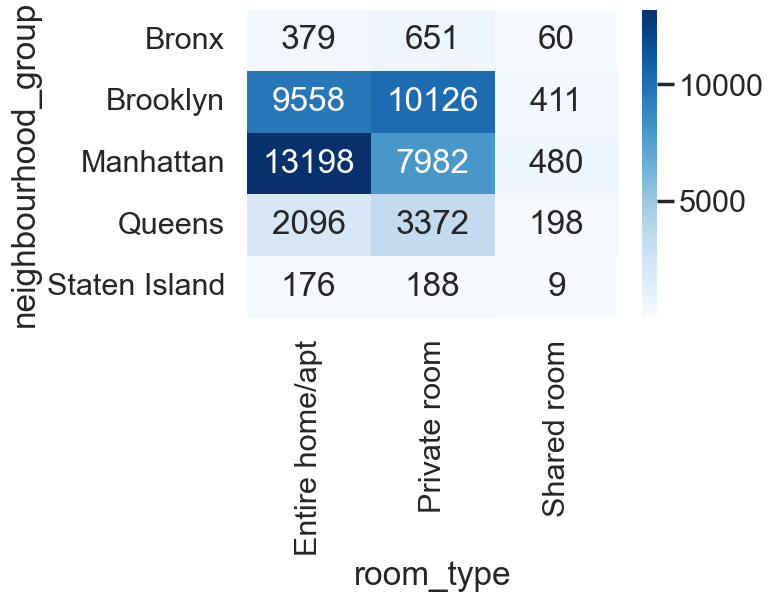

In [95]:
plt.figure(figsize=(6,4))
sns.heatmap(ct,annot=True,fmt='d',cmap='Blues')
plt.show()

**NO OF ROOM TYPE IN EACH TOP 5 NEIGHBOUR HOOD**

In [96]:
abc=Top_5_Neighbourhood['neighbourhood']

In [97]:
abc

0          Williamsburg
1    Bedford-Stuyvesant
2                Harlem
3              Bushwick
4       Upper West Side
Name: neighbourhood, dtype: object

In [98]:
# Heatmap of two categorical variable
ct2=pd.crosstab(df.loc[df['neighbourhood'].isin(abc),'neighbourhood'],df['room_type'])

#NO OF ROOM TYPE IN THE POPULAR NEIGHBOURHOOD

In [99]:
ct2

room_type,Entire home/apt,Private room,Shared room
neighbourhood,,,
Bedford-Stuyvesant,1591,2034,85
Bushwick,678,1718,66
Harlem,1036,1573,49
Upper West Side,1256,675,40
Williamsburg,1890,1997,32


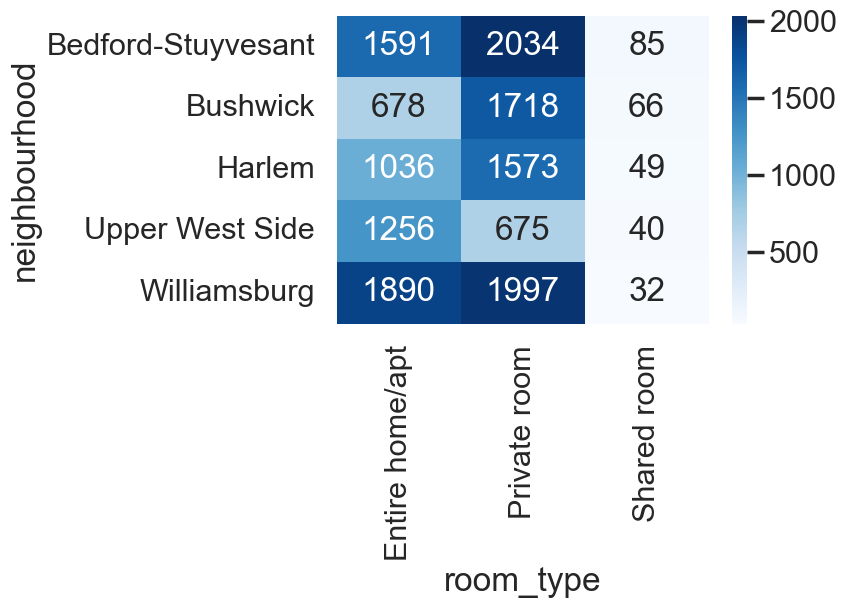

In [100]:
plt.figure(figsize=(6,4))
sns.heatmap(ct2,annot=True,fmt='d',cmap='Blues')
plt.show()

**top_5_last_review_airbnb**

In [101]:
numerical_cols

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [102]:
top_5_last_review_airbnb=df.sort_values(by=['last_review_year','last_review_month','last_review_date'],ascending=False).head()

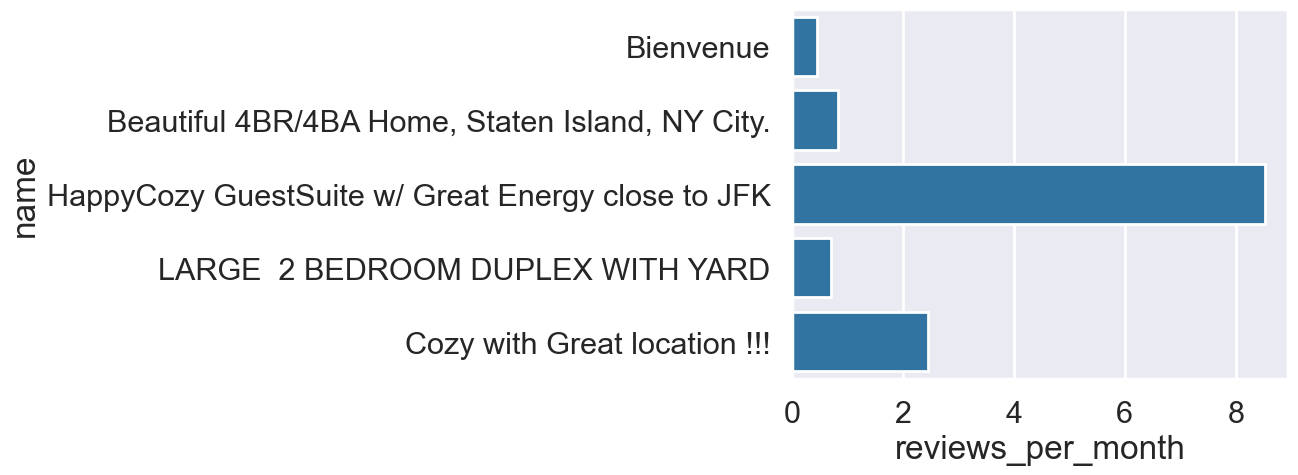

In [103]:
sns.barplot(data=top_5_last_review_airbnb, y='name',x='reviews_per_month')
plt.show()

**Price List of the Top 5 Recently Reviewed Airbnbs**

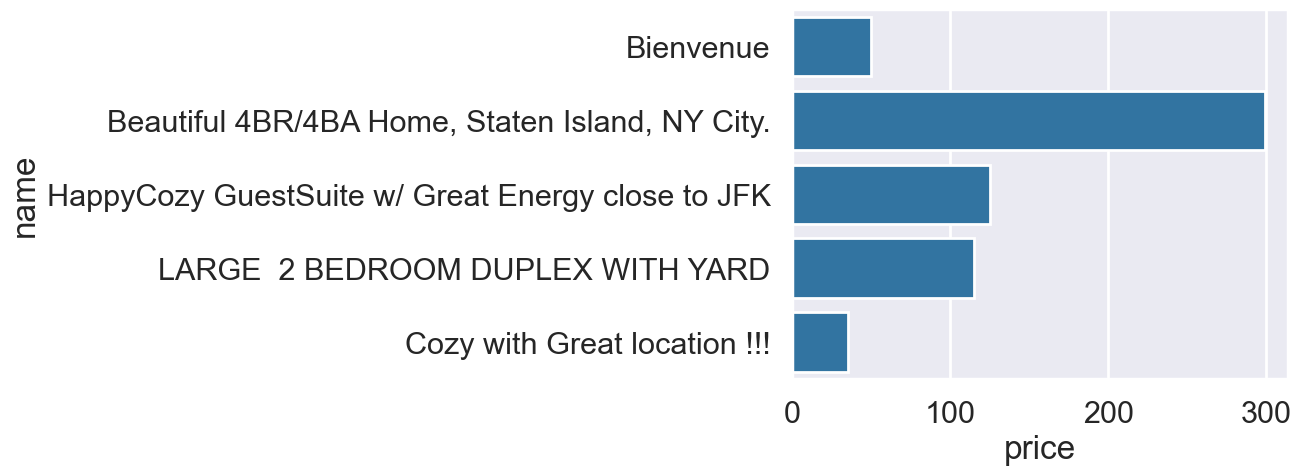

In [104]:
sns.barplot(data=top_5_last_review_airbnb, y='name',x='price')
plt.show()

**longititude and latitude of the Top 5 Recently Reviewed Airbnbs**

<Axes: xlabel='longitude', ylabel='latitude'>

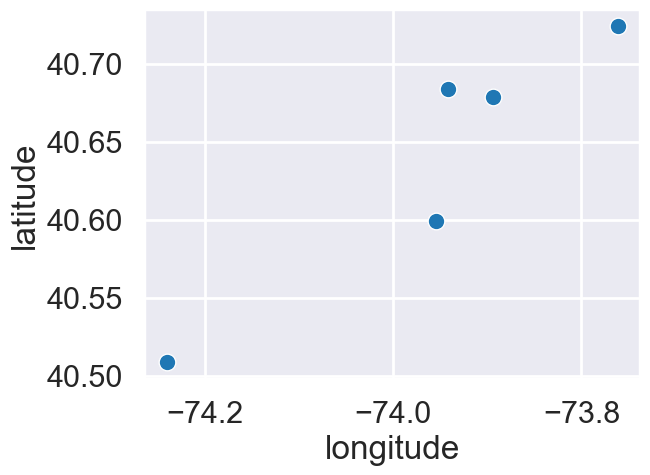

In [105]:
sns.scatterplot(data=top_5_last_review_airbnb,x='longitude', y= 'latitude',)

sns.barplot(data=top_5_last_review_airbnb, y='name',x='minimum_nights')
plt.show()

**MINIMUM NIGHTS of the Top 5 Recently Reviewed Airbnbs**

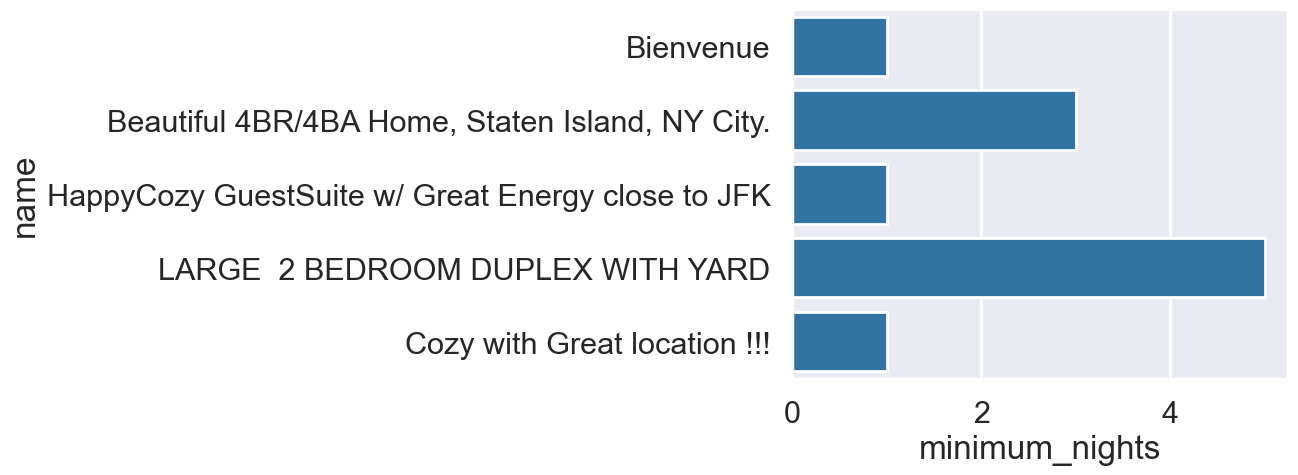

In [106]:
sns.barplot(data=top_5_last_review_airbnb, y='name',x='minimum_nights')
plt.show()

**PRICE DISTRIBUTION IS TOP 5 NEIGHBOURHOOD**

In [107]:
Top_5_Neighbourhood

,neighbourhood,count
0,Williamsburg,3919
1,Bedford-Stuyvesant,3710
2,Harlem,2658
3,Bushwick,2462
4,Upper West Side,1971


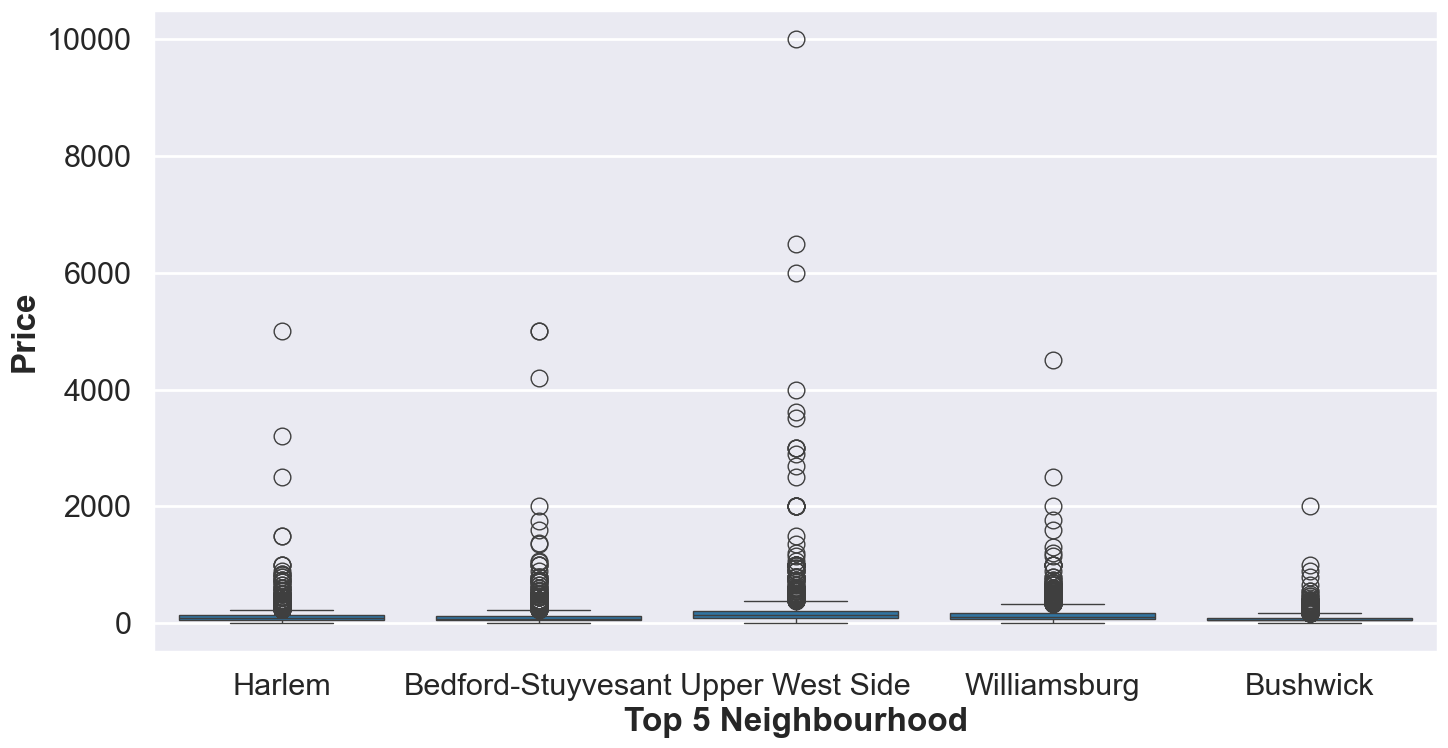

In [108]:
plt.figure(figsize=(15,8))
sns.set_context("poster")
sns.set_style("darkgrid")
sns.boxplot(data=df[df['neighbourhood'].isin(Top_5_Neighbourhood['neighbourhood'])],x='neighbourhood',y='price')
plt.xlabel('Top 5 Neighbourhood',fontweight='bold')
plt.ylabel('Price',fontweight='bold')
plt.tight_layout()
plt.show()

**PRICE DISTRIBUTION In NEIGHBOURHOOD GROUP**

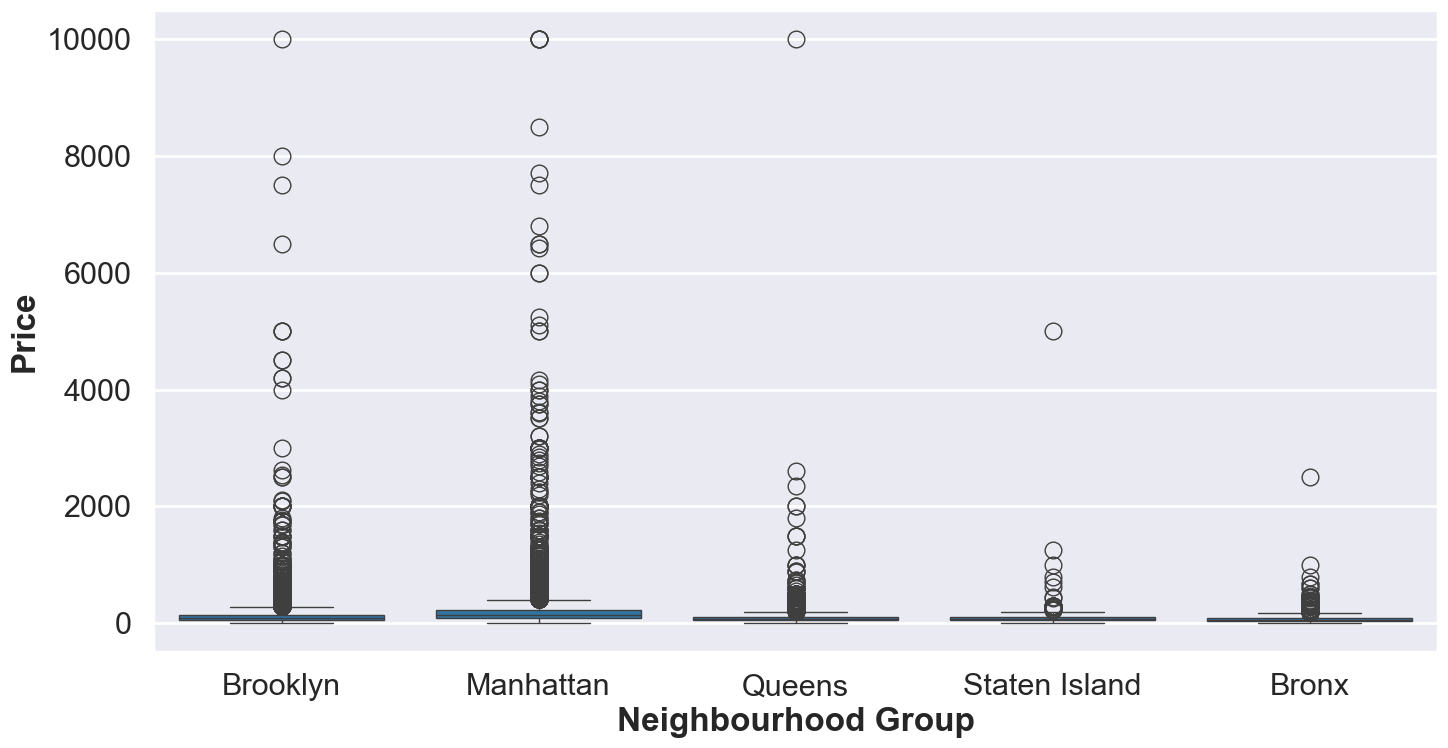

In [109]:
plt.figure(figsize=(15,8))
sns.set_context("poster")
sns.set_style("darkgrid")
sns.boxplot(data=df,x='neighbourhood_group',y='price')
plt.xlabel('Neighbourhood Group',fontweight='bold')
plt.ylabel('Price',fontweight='bold')

plt.tight_layout()
plt.show()

## CONVERTING CATEGORICAL VARIABLE INTO NUMERICAL VARIABLE

In [110]:
df.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,last_review_date
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,2018.0,10.0,19.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2019.0,5.0,21.0


**# LETS DROP ID , NAME AND HOST_ID AS THEY ARE IDENTIFIER AND DOESNT CARRY MEANINGFULL PATTERN**

In [111]:
df.drop(['id','name','host_id'],axis=1,inplace=True)

In [112]:
df.head(2)

,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,last_review_date
0,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,2018.0,10.0,19.0
1,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2019.0,5.0,21.0


In [113]:
df.drop('host_name',axis=1,inplace=True)

In [114]:
df.head(2)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,last_review_date
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,2018.0,10.0,19.0
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2019.0,5.0,21.0


In [115]:
from sklearn.preprocessing import OneHotEncoder

In [116]:
##create an instance of Onehotencoder
encoder=OneHotEncoder()

In [117]:
## perform fit and transform
encoded=encoder.fit_transform(df[['neighbourhood_group','room_type']]).toarray()

In [118]:
encoded

array([[0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       ...,
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 1., 0.]])

In [119]:
encoded_NG = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())

In [120]:
encoded_NG.head()

,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [121]:
df= df.reset_index(drop=True)

In [122]:
encoded_NG=encoded_NG.reset_index(drop=True)

In [123]:
new_df= pd.concat([df,encoded_NG],axis=1)

In [124]:
new_df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,...,last_review_month,last_review_date,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,...,10.0,19.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,...,5.0,21.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,...,7.0,5.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,...,11.0,19.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [125]:
new_df.drop('neighbourhood_group',axis=1,inplace=True)

In [126]:
new_df.drop('room_type',axis=1,inplace=True)


In [127]:
new_df.head()


,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,last_review_date,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,Kensington,40.64749,-73.97237,149,1,9,0.21,6,365,2018.0,10.0,19.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Midtown,40.75362,-73.98377,225,1,45,0.38,2,355,2019.0,5.0,21.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,Harlem,40.80902,-73.94190,150,3,0,0.00,1,365,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,Clinton Hill,40.68514,-73.95976,89,1,270,4.64,1,194,2019.0,7.0,5.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,East Harlem,40.79851,-73.94399,80,10,9,0.10,1,0,2018.0,11.0,19.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [128]:
count_neighbourhood = df['neighbourhood'].value_counts()

In [129]:
count_neighbourhood

neighbourhood
Williamsburg          3919
Bedford-Stuyvesant    3710
Harlem                2658
Bushwick              2462
Upper West Side       1971
                      ... 
Richmondtown             1
New Dorp                 1
Rossville                1
Woodrow                  1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [130]:
new_df['neighbourhood_encoded']=new_df['neighbourhood'].map(count_neighbourhood)


In [131]:
new_df.head()

,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,...,last_review_date,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,neighbourhood_encoded
0,Kensington,40.64749,-73.97237,149,1,9,0.21,6,365,2018.0,...,19.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,175
1,Midtown,40.75362,-73.98377,225,1,45,0.38,2,355,2019.0,...,21.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1545
2,Harlem,40.80902,-73.94190,150,3,0,0.00,1,365,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2658
3,Clinton Hill,40.68514,-73.95976,89,1,270,4.64,1,194,2019.0,...,5.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,572
4,East Harlem,40.79851,-73.94399,80,10,9,0.10,1,0,2018.0,...,19.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1117


In [132]:
new_df.drop('neighbourhood',axis=1,inplace=True)

In [133]:
new_df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,last_review_date,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,neighbourhood_encoded
0,40.64749,-73.97237,149,1,9,0.21,6,365,2018.0,10.0,19.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,175
1,40.75362,-73.98377,225,1,45,0.38,2,355,2019.0,5.0,21.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1545
2,40.80902,-73.94190,150,3,0,0.00,1,365,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2658
3,40.68514,-73.95976,89,1,270,4.64,1,194,2019.0,7.0,5.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,572
4,40.79851,-73.94399,80,10,9,0.10,1,0,2018.0,11.0,19.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1117


In [134]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48884 entries, 0 to 48883
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   latitude                           48884 non-null  float64
 1   longitude                          48884 non-null  float64
 2   price                              48884 non-null  int64  
 3   minimum_nights                     48884 non-null  int64  
 4   number_of_reviews                  48884 non-null  int64  
 5   reviews_per_month                  48884 non-null  float64
 6   calculated_host_listings_count     48884 non-null  int64  
 7   availability_365                   48884 non-null  int64  
 8   last_review_year                   48884 non-null  float64
 9   last_review_month                  48884 non-null  float64
 10  last_review_date                   48884 non-null  float64
 11  neighbourhood_group_Bronx          48884 non-null  flo

In [136]:
df.to_csv('Updated_DataSet/Aryan_Dangol_AIRBNB_NYC_CLEANED_DATASET.csv')